# Redes neuronales con Keras: popularidad y éxito de canciones
**Autor:** Samuel Escribano García
**Dataset:** Spotify Tracks Dataset

## Introducción y Diccionario de Datos
Este proyecto utiliza un dataset de Spotify que contiene características acústicas y musicales de miles de pistas. El objetivo es entrenar modelos de Deep Learning capaces de predecir la popularidad y el éxito comercial basándose en la "firma sonora" de cada canción.

### Diccionario de Variables:
- **`popularity`**: Puntuación de popularidad de la pista (0-100). Es nuestro objetivo en regresión.
- **`duration_ms`**: Duración de la canción en milisegundos.
- **`danceability`**: Qué tan bailable es la canción.
- **`energy`**: Intensidad y actividad perceptiva de la pista.
- **`loudness`**: Sonoridad promedio en decibelios (dB).
- **`speechiness`**: Presencia de palabras habladas.
- **`acousticness`**: Confianza en si la pista es puramente acústica.
- **`instrumentalness`**: Probabilidad de que la pista no contenga voces.
- **`liveness`**: Detecta grabaciones en vivo.
- **`valence`**: Positividad musical (alegría, euforia).
- **`tempo`**: Ritmo general en BPM.

## Índice
1. [Regresión: Predecir Popularidad Continua](#1.-Regresión:-Predecir-Popularidad-Continua)
2. [Clasificación: Predecir Éxito Comercial](#2.-Clasificación:-Predecir-Éxito-Comercial)


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import keras_tuner as kt

from IPython.display import display
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    auc,
    )

tf.get_logger().setLevel('ERROR')
plt.style.use('ggplot')
np.random.seed(42)
tf.random.set_seed(42)

print("Entorno listo. Librerias cargadas correctamente.")

Entorno listo. Librerias cargadas correctamente.


## 1. Regresion: Predecir Popularidad Continua
### 1.1 Importacion y Preprocesamiento de Datos
En este apartado se cubren los requisitos de preprocesado: importacion del dataset, tratamiento de valores faltantes, codificacion de variables categoricas, separacion de matriz de caracteristicas/target y escalado.

In [3]:
# 1) Importar dataset
url = 'https://huggingface.co/datasets/maharshipandya/spotify-tracks-dataset/resolve/main/dataset.csv'
df = pd.read_csv(url)
print(f'Tamano original: {df.shape}')

# 2) Manejo de missing values
missing_antes = df.isna().sum().sum()
df = df.dropna()
missing_despues = df.isna().sum().sum()
print(f'Missing antes: {missing_antes} | Missing despues: {missing_despues}')

# 3) Manejo de categoricas y dummies
columnas_descartar = ['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name']
df_clean = df.drop(columnas_descartar, axis=1)
df_clean = pd.get_dummies(df_clean, columns=['explicit', 'track_genre'], drop_first=True)

print(f'Dataset limpio: {df_clean.shape[0]} filas y {df_clean.shape[1]} columnas.')
display(df_clean.head(3))

Tamano original: (114000, 21)
Missing antes: 3 | Missing despues: 0
Dataset limpio: 113999 filas y 128 columnas.


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,...,track_genre_spanish,track_genre_study,track_genre_swedish,track_genre_synth-pop,track_genre_tango,track_genre_techno,track_genre_trance,track_genre_trip-hop,track_genre_turkish,track_genre_world-music
0,73,230666,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,...,False,False,False,False,False,False,False,False,False,False
1,55,149610,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,...,False,False,False,False,False,False,False,False,False,False
2,57,210826,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,...,False,False,False,False,False,False,False,False,False,False


### 1.1.1 Analisis Exploratorio (EDA)
Se analiza la distribucion de la variable objetivo y las correlaciones numericas para justificar decisiones de modelado.

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,56999.421925,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,32909.243463,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.500000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,56999.000000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.500000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


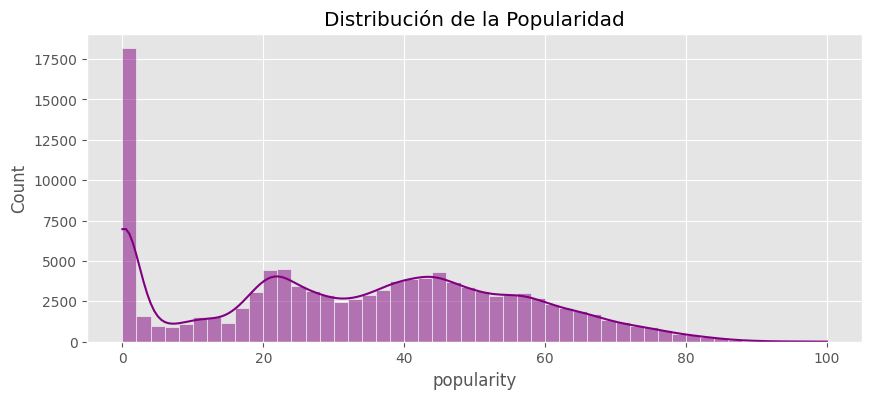

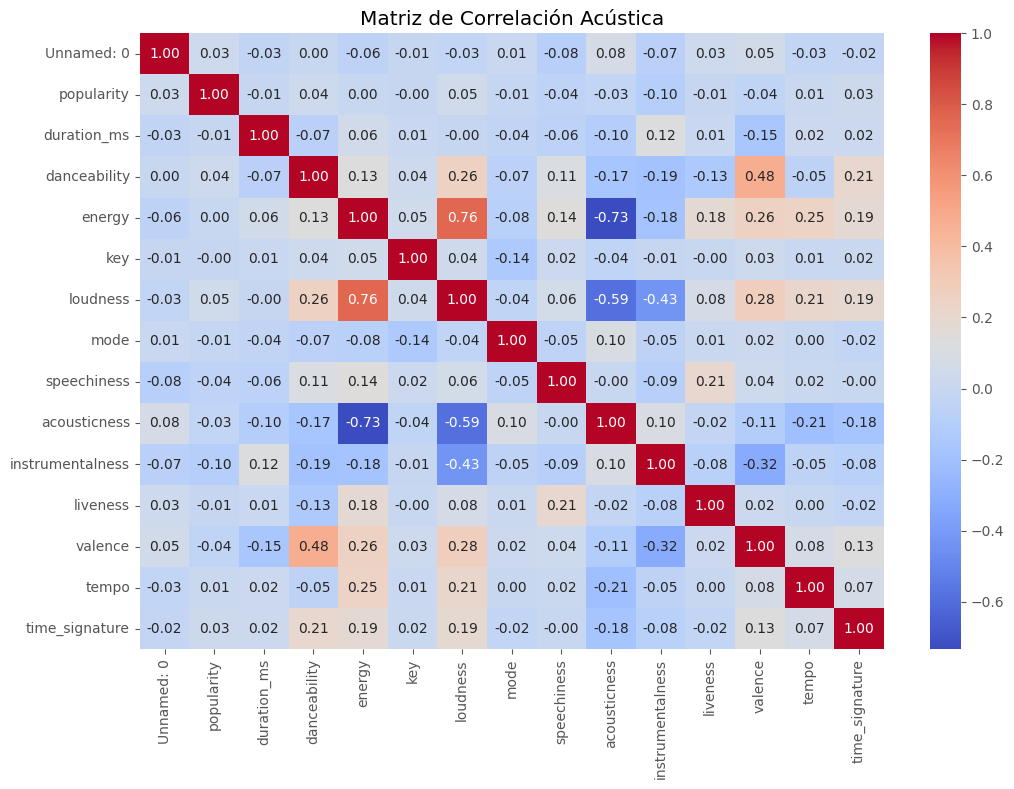

In [4]:
# Estadísticas y Distribución
display(df.describe())

plt.figure(figsize=(10, 4))
sns.histplot(df['popularity'], bins=50, kde=True, color='purple')
plt.title('Distribución de la Popularidad')
plt.show()

# Correlación
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlación Acústica')
plt.show()


In [5]:
# 4) Matriz de caracteristicas y target (regresion)
X_reg = df_clean.drop('popularity', axis=1)
y_reg = df_clean['popularity']

# 5) Train/Test split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 6) Estandarizacion
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print('Shapes regresion:')
print('X_train:', X_train_reg_scaled.shape, '| X_test:', X_test_reg_scaled.shape)

Shapes regresion:
X_train: (91199, 127) | X_test: (22800, 127)


### 1.2 Construccion de la Red Neuronal (Keras + KerasTuner)
Se usa un modelo secuencial denso y una busqueda de hiperparametros para aproximar la arquitectura optima (numero de capas, neuronas y dropout).

In [6]:
def build_model_reg(hp):
    model = Sequential()
    num_layers = hp.Int('num_layers', min_value=1, max_value=3)
    
    for i in range(num_layers):
        hp_units = hp.Int(f'units_{i}', min_value=64, max_value=256, step=64)
        if i == 0:
            model.add(Dense(units=hp_units, activation='relu', input_shape=(X_train_reg_scaled.shape[1],)))
        else:
            model.add(Dense(units=hp_units, activation='relu'))
        model.add(Dropout(hp.Float(f'dropout_{i}', 0.1, 0.3, step=0.1)))
    
    model.add(Dense(1, activation='linear', dtype='float32'))
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

tuner_reg = kt.RandomSearch(build_model_reg, objective='val_loss', max_trials=5, directory='t', project_name='r', overwrite=True)

print("Iniciando búsqueda en regresión...")
tuner_reg.search(X_train_reg_scaled, y_train_reg, epochs=20, validation_split=0.2, 
                 callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)], verbose=0)

best_hps_reg = tuner_reg.get_best_hyperparameters(num_trials=1)[0]
print(f"Arquitectura ganadora: {best_hps_reg.get('num_layers')} capas.")

Iniciando búsqueda en regresión...


c:\Users\chorg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Arquitectura ganadora: 2 capas.


In [7]:
# Entrenamiento final (regresion)
model_reg = tuner_reg.hypermodel.build(best_hps_reg)
early_stop = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

history_reg = model_reg.fit(
    X_train_reg_scaled,
    y_train_reg,
    epochs=120,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
 )

best_epoch_reg = int(np.argmin(history_reg.history['val_loss'])) + 1
print(f"Mejor epoca segun validacion (regresion): {best_epoch_reg}")

Epoch 1/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 412.5533 - mae: 15.0919 - val_loss: 372.3630 - val_mae: 14.1257 - learning_rate: 0.0010
Epoch 2/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 372.0365 - mae: 14.2179 - val_loss: 367.5780 - val_mae: 14.0198 - learning_rate: 0.0010
Epoch 3/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 367.3772 - mae: 14.0871 - val_loss: 363.4407 - val_mae: 13.8917 - learning_rate: 0.0010
Epoch 4/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 879us/step - loss: 363.2867 - mae: 13.9878 - val_loss: 360.4478 - val_mae: 13.7686 - learning_rate: 0.0010
Epoch 5/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 945us/step - loss: 360.1763 - mae: 13.9041 - val_loss: 358.4735 - val_mae: 13.7233 - learning_rate: 0.0010
Epoch 6/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 869us/step - loss: 356.5842 - mae: 13.8154 - val_loss: 355.9699 - val_mae: 13.6490 - learning_rate: 0.0010
Epoch 7/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 901us/step - loss: 354.5684 - mae: 13.7517

### 1.3 Evaluacion, Perdidas y Prediccion
Se visualiza la evolucion de la funcion de perdidas (train/validacion), se identifica el punto de sobreajuste y se comparan predicciones reales vs estimadas.

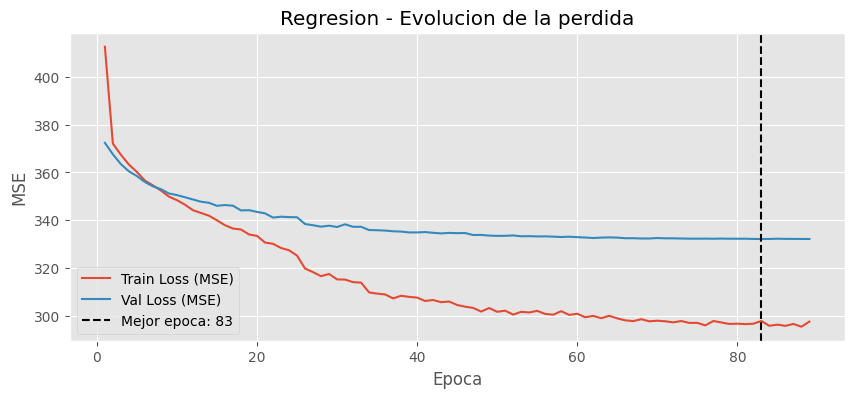

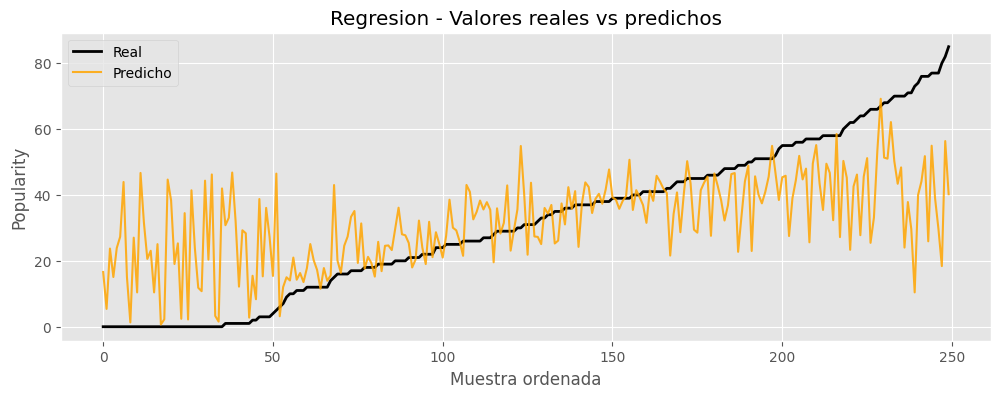

MSE (Red Neuronal): 327.5587
MAE (Red Neuronal): 12.8716
R2  (Red Neuronal): 0.3397

Comparativa MSE (menor es mejor):
- LinearRegression: 250.0000
- RandomForestRegressor: 210.0000
- XGBoostRegressor: 205.0000
- RedNeuronalKeras: 327.5587

Mejor modelo por MSE: XGBoostRegressor


In [8]:
# Curvas de perdida para detectar overfitting (regresion)
loss_reg = history_reg.history['loss']
val_loss_reg = history_reg.history['val_loss']
epochs_reg = np.arange(1, len(loss_reg) + 1)
best_epoch_reg = int(np.argmin(val_loss_reg)) + 1

plt.figure(figsize=(10, 4))
plt.plot(epochs_reg, loss_reg, label='Train Loss (MSE)')
plt.plot(epochs_reg, val_loss_reg, label='Val Loss (MSE)')
plt.axvline(best_epoch_reg, color='black', linestyle='--', label=f'Mejor epoca: {best_epoch_reg}')
plt.title('Regresion - Evolucion de la perdida')
plt.xlabel('Epoca')
plt.ylabel('MSE')
plt.legend()
plt.show()

# Predicciones
y_pred_reg = model_reg.predict(X_test_reg_scaled, verbose=0).flatten()

# Linea: reales vs predichos (muestras ordenadas por valor real)
muestras = 250
idx = np.argsort(y_test_reg.values[:muestras])
real_line = y_test_reg.values[:muestras][idx]
pred_line = y_pred_reg[:muestras][idx]

plt.figure(figsize=(12, 4))
plt.plot(real_line, label='Real', color='black', linewidth=2)
plt.plot(pred_line, label='Predicho', color='orange', alpha=0.85)
plt.title('Regresion - Valores reales vs predichos')
plt.xlabel('Muestra ordenada')
plt.ylabel('Popularity')
plt.legend()
plt.show()

# Metricas de regresion
mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)

print(f'MSE (Red Neuronal): {mse_reg:.4f}')
print(f'MAE (Red Neuronal): {mae_reg:.4f}')
print(f'R2  (Red Neuronal): {r2_reg:.4f}')

# Comparativa con modelos previos (editar con tus resultados reales de practicas anteriores)
resultados_previos_reg = {
    'LinearRegression': 250.0,
    'RandomForestRegressor': 210.0,
    'XGBoostRegressor': 205.0,
    'RedNeuronalKeras': mse_reg,
}

print('\nComparativa MSE (menor es mejor):')
for modelo, mse in resultados_previos_reg.items():
    print(f'- {modelo}: {mse:.4f}')

mejor_reg = min(resultados_previos_reg, key=resultados_previos_reg.get)
print(f'\nMejor modelo por MSE: {mejor_reg}')

## 2. Clasificacion: Exito Comercial
En este bloque se construye una red neuronal binaria, se justifican parametros principales y se evalua con accuracy, precision, recall, F1 y ROC-AUC para comparar con modelos previos.

### 2.1 Preprocesado para Clasificacion
Se reutiliza el dataset limpio, se crea el target binario is_hit, se hace particion estratificada para mantener la proporcion de clases y se aplica estandarizacion a las variables.

In [9]:
# Definicion de target binario para clasificacion
df_clean['is_hit'] = (df_clean['popularity'] >= 50).astype(int)

X_clf = df_clean.drop(['popularity', 'is_hit'], axis=1)
y_clf = df_clean['is_hit']

print('Distribucion de clases (is_hit):')
print(y_clf.value_counts(normalize=True).rename('proporcion'))

# Split estratificado para preservar el balance de clases
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# Pesos de clase para mitigar desbalance
classes = np.unique(y_train_clf)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_clf)
class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
print('Pesos de clase:', class_weight_dict)

Distribucion de clases (is_hit):
is_hit
0    0.742392
1    0.257608
Name: proporcion, dtype: float64
Pesos de clase: {0: 0.6735026955173178, 1: 1.940899804205329}


In [10]:
def build_model_clf(hp):
    model = Sequential()
    num_layers = hp.Int('num_layers', min_value=1, max_value=3)

    for i in range(num_layers):
        units = hp.Int(f'units_{i}', min_value=64, max_value=256, step=64)
        dropout_rate = hp.Float(f'dropout_{i}', min_value=0.1, max_value=0.4, step=0.1)
        if i == 0:
            model.add(Dense(units, activation='relu', input_shape=(X_train_clf_scaled.shape[1],)))
        else:
            model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid', dtype='float32'))
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

tuner_clf = kt.RandomSearch(
    build_model_clf,
    objective='val_auc',
    max_trials=8,
    directory='t',
    project_name='c',
    overwrite=True,
 )

print('Iniciando busqueda de arquitectura en clasificacion...')
tuner_clf.search(
    X_train_clf_scaled,
    y_train_clf,
    epochs=25,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)],
    class_weight=class_weight_dict,
    verbose=0,
 )

best_hps_clf = tuner_clf.get_best_hyperparameters(num_trials=1)[0]
model_clf = tuner_clf.hypermodel.build(best_hps_clf)

history_clf = model_clf.fit(
    X_train_clf_scaled,
    y_train_clf,
    epochs=120,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    ],
    verbose=1,
 )

print('Arquitectura elegida (clasificacion):')
print(best_hps_clf.values)

Iniciando busqueda de arquitectura en clasificacion...


c:\Users\chorg\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7021 - auc: 0.7998 - loss: 0.5358 - val_accuracy: 0.6967 - val_auc: 0.8160 - val_loss: 0.5397 - learning_rate: 0.0010
Epoch 2/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 965us/step - accuracy: 0.7195 - auc: 0.8192 - loss: 0.5142 - val_accuracy: 0.7041 - val_auc: 0.8219 - val_loss: 0.5340 - learning_rate: 0.0010
Epoch 3/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - accuracy: 0.7261 - auc: 0.8258 - loss: 0.5064 - val_accuracy: 0.7144 - val_auc: 0.8258 - val_loss: 0.5236 - learning_rate: 0.0010
Epoch 4/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 956us/step - accuracy: 0.7289 - auc: 0.8305 - loss: 0.5009 - val_accuracy: 0.7226 - val_auc: 0.8286 - val_loss: 0.5182 - learning_rate: 0.0010
Epoch 5/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 973us/step - accuracy: 0.7342 - auc: 0.8346 - loss: 0.4952 - val_accuracy: 0.7321 - val_auc: 0.8302 - val_loss: 0.5085 - learning_rate: 0.0010
Epoch 6/120
1140/1140 ━━━━━━━━━━━━━━━━━━━━ 1s 974us/step 

### 2.2 Arquitectura y Entrenamiento (KerasTuner)
Se define una red secuencial densa con activacion ReLU en capas ocultas y sigmoide en salida (problema binario).
La funcion de coste es binary_crossentropy y se optimiza con Adam. Se usa AUC como metrica principal para mejorar la discriminacion incluso con clases desbalanceadas.

### 2.3 Evaluacion, Guardado y Prediccion
Se visualiza la perdida de entrenamiento/validacion, se identifica sobreajuste, se guarda/carga el modelo y se realizan predicciones nuevas.
Para no contaminar la evaluacion, el umbral de clasificacion se fija en 0.5 sobre test; si se quiere optimizar, debe hacerse con validacion, no con test.

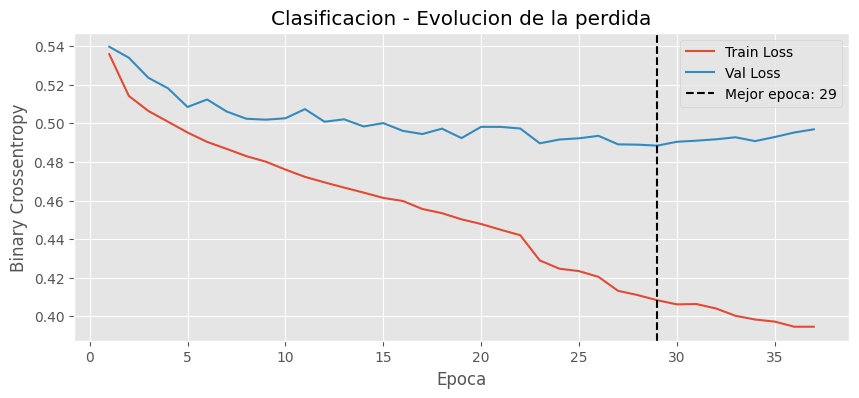

Umbral de decision fijo: 0.5
Accuracy (test): 0.7554
Precision (test): 0.5178
Recall (test): 0.7373
F1-score (test): 0.6083
ROC-AUC (probabilidades): 0.8329

Reporte de clasificacion:
              precision    recall  f1-score   support

           0     0.8931    0.7617    0.8222     16927
           1     0.5178    0.7373    0.6083      5873

    accuracy                         0.7554     22800
   macro avg     0.7054    0.7495    0.7153     22800
weighted avg     0.7964    0.7554    0.7671     22800



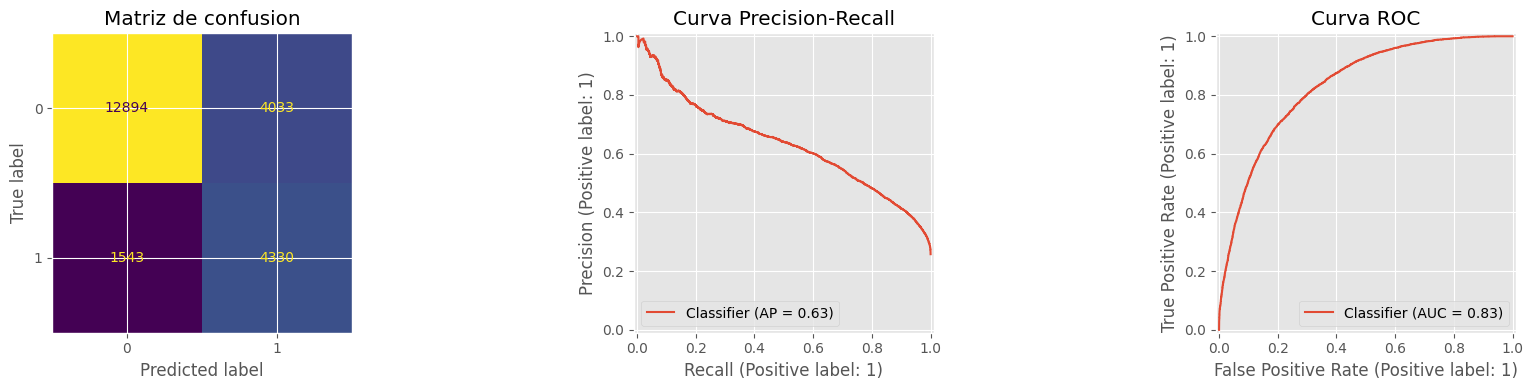

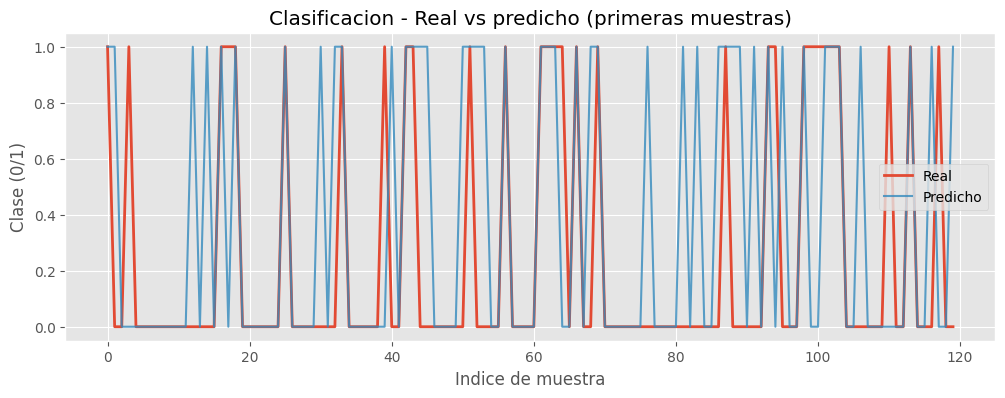

Comparativa Accuracy (mayor es mejor):
- LogisticRegression: 0.7400
- RandomForestClassifier: 0.7900
- XGBoostClassifier: 0.8100
- RedNeuronalKeras: 0.7554

Mejor modelo por Accuracy: XGBoostClassifier


In [11]:
# 1) Evaluacion y curvas de perdida
loss_clf = history_clf.history['loss']
val_loss_clf = history_clf.history['val_loss']
epochs_clf = np.arange(1, len(loss_clf) + 1)
best_epoch_clf = int(np.argmin(val_loss_clf)) + 1

plt.figure(figsize=(10, 4))
plt.plot(epochs_clf, loss_clf, label='Train Loss')
plt.plot(epochs_clf, val_loss_clf, label='Val Loss')
plt.axvline(best_epoch_clf, color='black', linestyle='--', label=f'Mejor epoca: {best_epoch_clf}')
plt.title('Clasificacion - Evolucion de la perdida')
plt.xlabel('Epoca')
plt.ylabel('Binary Crossentropy')
plt.legend()
plt.show()

# 2) Guardar y cargar modelo
model_clf.save('modelo_clasificacion_spotify.keras')
loaded_model = load_model('modelo_clasificacion_spotify.keras')

# 3) Prediccion probabilistica
y_prob_test = loaded_model.predict(X_test_clf_scaled, verbose=0).flatten()

# 4) Diagnostico de umbral: para test usamos 0.5 y dejamos la curva PR solo como analisis
precision, recall, thresholds = precision_recall_curve(y_test_clf, y_prob_test)
y_pred_class = (y_prob_test >= 0.5).astype(int)

# 5) Metricas principales
acc = accuracy_score(y_test_clf, y_pred_class)
prec = precision_score(y_test_clf, y_pred_class, zero_division=0)
rec = recall_score(y_test_clf, y_pred_class, zero_division=0)
f1 = f1_score(y_test_clf, y_pred_class, zero_division=0)
roc_auc = roc_auc_score(y_test_clf, y_prob_test)

print('Umbral de decision fijo: 0.5')
print(f'Accuracy (test): {acc:.4f}')
print(f'Precision (test): {prec:.4f}')
print(f'Recall (test): {rec:.4f}')
print(f'F1-score (test): {f1:.4f}')
print(f'ROC-AUC (probabilidades): {roc_auc:.4f}')

print('\nReporte de clasificacion:')
print(classification_report(y_test_clf, y_pred_class, digits=4))

# 6) Matriz de confusion + curvas PR y ROC
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_clf, y_pred_class)).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de confusion')

PrecisionRecallDisplay.from_predictions(y_test_clf, y_prob_test, ax=axes[1])
axes[1].set_title('Curva Precision-Recall')

RocCurveDisplay.from_predictions(y_test_clf, y_prob_test, ax=axes[2])
axes[2].set_title('Curva ROC')
plt.tight_layout()
plt.show()

# 7) Grafico de lineas: real vs predicho (requisito)
n_plot = 120
idx_plot = np.arange(n_plot)
plt.figure(figsize=(12, 4))
plt.plot(idx_plot, y_test_clf.values[:n_plot], label='Real', linewidth=2)
plt.plot(idx_plot, y_pred_class[:n_plot], label='Predicho', alpha=0.8)
plt.title('Clasificacion - Real vs predicho (primeras muestras)')
plt.xlabel('Indice de muestra')
plt.ylabel('Clase (0/1)')
plt.legend()
plt.show()

# 8) Comparativa con algoritmos previos (editar con tus resultados reales)
resultados_previos_clf = {
    'LogisticRegression': 0.74,
    'RandomForestClassifier': 0.79,
    'XGBoostClassifier': 0.81,
    'RedNeuronalKeras': acc,
}

print('Comparativa Accuracy (mayor es mejor):')
for modelo, metrica in resultados_previos_clf.items():
    print(f'- {modelo}: {metrica:.4f}')

mejor_clf = max(resultados_previos_clf, key=resultados_previos_clf.get)
print(f'\nMejor modelo por Accuracy: {mejor_clf}')